# **Problem Statement**

FlipItNews is building an AI-powered content discovery platform to enhance financial awareness and personalized news consumption for modern users. With thousands of news articles being published daily, manually categorizing content becomes inefficient and difficult to scale.

The goal of this project is to design and implement an NLP-driven intelligent news classification engine capable of automatically identifying and assigning categories such as Business, Politics, Technology, Sports, and Entertainment to news articles.

The project will involve:

textual data preprocessing,

stopword removal,

tokenization,

lemmatization,

text vectorization using Bag of Words and TF-IDF,

and training multiple machine learning classification models.

The models will be evaluated based on accuracy, precision, recall, F1-score, and confusion matrix analysis to determine the best-performing solution for real-world deployment.

In [355]:
# !pip install gensim
# !pip install contractions
# !pip install spacy
# !python -m spacy download en_core_web_sm

import pandas as pd
import numpy as np
import re
import time
import logging
import warnings
import contractions
import nltk
from functools import wraps
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from sklearn.preprocessing import LabelEncoder
import string
from abc import ABC, abstractmethod
from dataclasses import dataclass
from typing import Any, Dict, Tuple
import pickle
import spacy # Added spacy import
import gensim.downloader as api # Added gensim.downloader import

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import defaultdict, Counter
from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression

# Download NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download("omw-1.4", quiet=True)

from typing import (
    List,
    Set,
    Union
)

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)

from nltk.tokenize import (
    word_tokenize,
    sent_tokenize
)

from nltk.stem import (
    WordNetLemmatizer,
    PorterStemmer
)

warnings.filterwarnings("ignore")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [356]:
# Reading the data file
df=pd.read_csv('/content/flipitnews-data.csv')
df.head()

,Category,Article
0,Technology,tv future in the hands of viewers with home th...
1,Business,worldcom boss left books alone former worldc...
2,Sports,tigers wary of farrell gamble leicester say ...
3,Sports,yeading face newcastle in fa cup premiership s...
4,Entertainment,ocean s twelve raids box office ocean s twelve...


<Axes: xlabel='Category'>

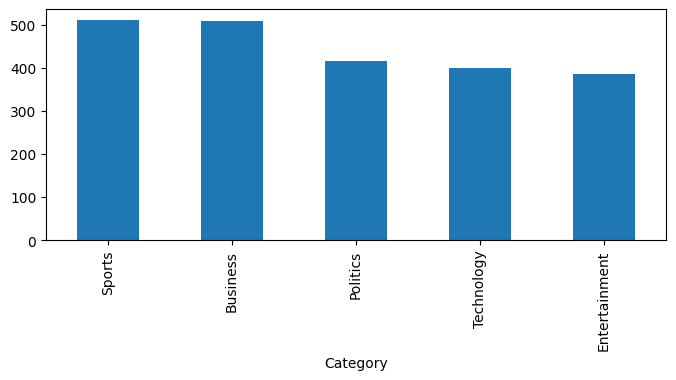

In [357]:
# @title Articles per Category
plt.figure(figsize=(8,3))
df['Category'].value_counts().plot(kind='bar')

# **Enterprise-Level EDA**

In [358]:
warnings.filterwarnings("ignore")
# =========================
# LOGGING CONFIGURATION
# =========================

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

# ==============================
# CONFIGURATION & INFRASTRUCTURE
# ==============================1

@dataclass
class PipelineConfig:

    figure_size: tuple = (12, 5)

    category_plot_palette: str = "viridis"

    boxplot_palette: str = "Set2"

    top_k_ngrams: int = 10

    ngram_size: int = 2

    random_state: int = 42

# ============================================================
# MODEL CONFIGURATION
# ============================================================

@dataclass(frozen=True)
class ModelConfig:

    random_state: int = 42

    n_neighbors: int = 5

    n_estimators: int = 200

@dataclass(frozen=True)
class NLPConfig:

    """
    Immutable NLP configuration object.
    """

    lowercase: bool = True

    remove_non_letters: bool = True

    remove_punctuation: bool = True

    tokenize: bool = True

    remove_stopwords: bool = True

    apply_stemming: bool = False

    apply_lemmatization: bool = True

    language: str = "english"

    minimum_token_length: int = 2

# ============================================================
# IMMUTABLE CONFIGURATION OBJECT
# ============================================================

@dataclass(frozen=True)
class FeatureEngineeringConfig:

    """
    Immutable runtime configuration.
    """

    word2Vec_vectorization_method: str = "word2vec"

    vectorization_method: str = "tfidf"

    test_size: float = 0.20

    random_state: int = 42

    max_features: Optional[int] = None # Changed to Optional[int]

    # Specific Vector Embedding Variables
    embedding_vector_size: int = 300        # Standard production feature space depth
    window_context: int = 5
    min_word_count: int = 2
    epochs: int = 10 # Added epochs parameter
    # Ensuring dataclass definition is refreshed


@dataclass(frozen=True)
class SemanticConfig:

    embedding_model: str = "fasttext-wiki-news-subwords-300"

    test_size: float = 0.20

    random_state: int = 42

    max_iter: int = 1000

In [359]:
# Decorators for tracking execution time and pipeline progress in application logs.
def timer(func):

    """
    Measures method execution time.
    """

    @wraps(func)

    def wrapper(*args, **kwargs):

        start_time = time.perf_counter()

        result = func(*args, **kwargs)

        end_time = time.perf_counter()

        logging.info(
            f"{func.__name__} "
            f"completed in "
            f"{end_time - start_time:.4f} sec"
        )

        return result

    return wrapper


def log_step(step_name: str):

    """
    Logs pipeline execution stages.
    """

    def decorator(func):

        @wraps(func)

        def wrapper(*args, **kwargs):

            logging.info(
                f"STARTED --> {step_name}"
            )

            result = func(*args, **kwargs)

            logging.info(
                f"COMPLETED --> {step_name}"
            )

            return result

        return wrapper

    return decorator

In [360]:
# ============================================================
# DATA VALIDATION ENGINE
# ============================================================

class DatasetValidator:

    """
    Centralized reusable dataset validation engine.
    """

    @staticmethod
    def validate(

            df: pd.DataFrame,

            required_columns: list
    ) -> None:

        # ----------------------------------------------------
        # DATAFRAME VALIDATION
        # ----------------------------------------------------

        if not isinstance(df, pd.DataFrame):

            raise TypeError(
                "Input must be a pandas DataFrame."
            )

        # ----------------------------------------------------
        # EMPTY DATAFRAME CHECK
        # ----------------------------------------------------

        if df.empty:

            raise ValueError(
                "Input dataframe is empty."
            )

        # ----------------------------------------------------
        # REQUIRED COLUMN VALIDATION
        # ----------------------------------------------------

        for column in required_columns:

            if column not in df.columns:

                raise ValueError(

                    f"Column '{column}' "
                    f"not found in dataframe."
                )

        logging.info(
            "Dataset validation successful."
        )

In [361]:
class RealTimeTextEDAPipeline:
    """
    Enterprise-grade NLP EDA Pipeline - Corrected for Clean Text Integration
    """

    def __init__(
            self,
            dataframe: pd.DataFrame,
            text_column: str,
            category_column: str,
            config: PipelineConfig = PipelineConfig()
    ):
        self.df = dataframe.copy()
        self.text_column = text_column
        self.category_column = category_column
        self.clean_text_column = "Clean_Article"  # Internal unified target token destination
        self.config = config
        self.label_encoder = LabelEncoder()
        self.validate_inputs()

        # Pull required linguistic resources locally
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()
        self.punctuation_regex = re.compile(f'[{re.escape(string.punctuation)}]')
        self.non_letter_regex = re.compile(r'[^a-zA-Z\s]')

    def validate_inputs(self) -> None:
      DatasetValidator.validate(
          df=self.df,
          required_columns=[
              self.text_column,
              self.category_column
          ]
      )

      logging.info("Input validation completed successfully.")

    @timer
    def run_structural_analysis(self):
        print("\n" + "=" * 70)
        print("STEP 1 : DATASET STRUCTURAL ANALYSIS")
        print("=" * 70)
        print(f"\nDataset Shape : {self.df.shape}")
        print(f"Dataset Columns: {self.df.columns.tolist()}")
        print("\nMissing Values:")
        print(self.df[[self.text_column, self.category_column]].isnull().sum())
        print(f"\nDuplicate Records: {self.df.duplicated().sum()}")
        print("\nCategory Distribution:")
        print(self.df[self.category_column].value_counts())
        return self

    # ========================================================
    # INJECTED CORE CORRECTION: INTERNAL PREPROCESSING FILTER
    # ========================================================
    def _clean_document_tokens(self, text: str) -> str:
        """Internal helper running high-accuracy text extraction loops."""
        if not isinstance(text, str):
            return ""
        # 1. Lowercase instantly
        text = text.lower()
        # 2. Extract structural punctuation and numerical noise
        text = self.non_letter_regex.sub('', text)
        text = self.punctuation_regex.sub('', text)
        # 3. Clean token boundaries against target stopwords
        tokens = text.split()
        filtered_tokens = [w for w in tokens if w not in self.stop_words]
        # 4. Lemmatize ONLY (Omitting crude Stemming to save dictionary roots)
        lemmatized_tokens = [self.lemmatizer.lemmatize(w) for w in filtered_tokens]
        return " ".join(lemmatized_tokens)

    @timer
    def engineer_text_features(self):
        logging.info("Generating corrected text metrics and target class label encodings.")

        # Ensure all 5 categories are encoded correctly
        self.df["Category_ID"] = self.label_encoder.fit_transform(self.df[self.category_column])

        # Run internal text transformations to guarantee correct metrics
        self.df[self.clean_text_column] = self.df[self.text_column].apply(self._clean_document_tokens)

        # Baseline text stats computed against raw dataset
        self.df["Character_Count"] = self.df[self.text_column].astype(str).apply(len)

        # Word stats are computed against clean text to avoid counting stopwords and punctuation
        self.df["Word_Count"] = self.df[self.clean_text_column].apply(lambda text: len(text.split()))

        self.df["Average_Word_Length"] = self.df[self.clean_text_column].apply(
            lambda text: np.mean([len(word) for word in text.split()]) if len(text.split()) > 0 else 0
        )

        logging.info("Feature engineering and token sanitization completed.")
        return self

    @timer
    def plot_category_distribution(self):
        plt.figure(figsize=(10, 5))
        sns.countplot(
            x=self.category_column,
            data=self.df,
            order=self.df[self.category_column].value_counts().index,
            palette=self.config.category_plot_palette
        )
        plt.title("Distribution of News Articles per Category", fontsize=13, fontweight="bold")
        plt.xlabel("Category")
        plt.ylabel("Count")
        plt.xticks(rotation=15)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()
        return self

    @timer
    def plot_text_length_analysis(self):
        plt.figure(figsize=(14, 5))

        plt.subplot(1, 2, 1)
        sns.boxplot(
            x=self.category_column,
            y="Word_Count",
            data=self.df,
            palette=self.config.boxplot_palette
        )
        plt.title("Clean Word Count Distribution Across Categories", fontsize=11, fontweight="bold")
        plt.xticks(rotation=20)

        plt.subplot(1, 2, 2)
        for category in self.df[self.category_column].unique():
            subset = self.df[self.df[self.category_column] == category]
            sns.kdeplot(
                subset["Word_Count"],
                label=category,
                fill=True,
                alpha=0.2
            )
        plt.title("Sanitized Word Density Distribution", fontsize=11, fontweight="bold")
        plt.xlabel("Word Count")
        plt.legend()
        plt.tight_layout()
        plt.show()
        return self

    @timer
    def analyze_vocabulary(self):
        # Build vocabulary from the clean text data to measure actual classification capacity
        vocabulary = set()
        for text in self.df[self.clean_text_column]:
            vocabulary.update(text.split())

        print("\n" + "=" * 70)
        print("STEP 2 : ACTUAL VOCABULARY ANALYSIS (CLEAN WORDS ONLY)")
        print("=" * 70)
        print(f"\nReal Vocabulary Size (Features Sent to Classifier Models): {len(vocabulary)}")
        return self

    @timer
    def generate_category_statistics(self):
        print("\n" + "=" * 70)
        print("STEP 3 : CATEGORY LEVEL ANALYTICS")
        print("=" * 70)
        stats_df = (
            self.df.groupby(self.category_column)[
                ["Character_Count", "Word_Count", "Average_Word_Length"]
            ]
            .mean()
            .round(2)
        )
        print(stats_df)
        return self

    @timer
    def generate_wordcloud(self):
        # Generate WordCloud using clean tokens to exclude noisy structural terms
        combined_text = " ".join(self.df[self.clean_text_column].astype(str))

        wordcloud = WordCloud(
            width=1000,
            height=500,
            background_color='white'
        ).generate(combined_text)

        plt.figure(figsize=(14, 6))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis("off")
        plt.title("Global WordCloud (Clean Structural Vocabulary Tokens)", fontsize=15, fontweight='bold')
        plt.show()
        return self

    @timer
    def extract_top_ngrams(self):
        print("\n" + "=" * 70)
        print(f"STEP 4 : TOP {self.config.top_k_ngrams} {self.config.ngram_size}-GRAMS")
        print("=" * 70)

        categories = self.df[self.category_column].unique()

        for category in categories:
            print(f"\nTop phrases in [{category.upper()}]")

            # Point to clean document column to reflect lemmatized text structures
            category_documents = self.df[self.df[self.category_column] == category][self.clean_text_column]

            try:
                # Dropping local stop_words filter assignment since our dataset is already clean
                vectorizer = CountVectorizer(
                    ngram_range=(self.config.ngram_size, self.config.ngram_size)
                )
                bag_matrix = vectorizer.fit_transform(category_documents)
                frequency_sum = bag_matrix.sum(axis=0)

                word_frequency = [
                    (word, frequency_sum[0, index])
                    for word, index in vectorizer.vocabulary_.items()
                ]

                sorted_frequencies = sorted(
                    word_frequency,
                    key=lambda item: item[1],
                    reverse=True
                )[:self.config.top_k_ngrams]

                for phrase, frequency in sorted_frequencies:
                    print(f"  • {phrase:<30} -> {frequency}")

            except ValueError:
                print("  Not enough text data found to process n-gram parameters.")

        return self

    @timer
    def generate_summary_report(self):
        print("\n" + "=" * 70)
        print("FINAL NLP EDA SUMMARY REPORT")
        print("=" * 70)

        report = {
            "Dataset Shape": self.df.shape,
            "Total Target Categories": self.df[self.category_column].nunique(),
            "Average Clean Word Count": round(self.df["Word_Count"].mean(), 2),
            "Average Character Count": round(self.df["Character_Count"].mean(), 2),
            "Duplicate Records Detected": self.df.duplicated().sum(),
            "Missing Text Values Found": self.df[self.text_column].isnull().sum()
        }

        for key, value in report.items():
            print(f"{key:<30}: {value}")
        return self

    @timer
    def execute_pipeline(self):
        logging.info("Starting Corrected Real-Time NLP EDA Engine Framework Instance.")
        (
            self
            .run_structural_analysis()
            .engineer_text_features()
            .plot_category_distribution()
            .plot_text_length_analysis()
            .analyze_vocabulary()
            .generate_category_statistics()
            .generate_wordcloud()
            .extract_top_ngrams()
            .generate_summary_report()
        )
        logging.info("Framework Pipeline Execution Complete. Payload matrices ready for classification.")
        return self.df


STEP 1 : DATASET STRUCTURAL ANALYSIS

Dataset Shape : (2225, 2)
Dataset Columns: ['Category', 'Article']

Missing Values:
Article     0
Category    0
dtype: int64

Duplicate Records: 99

Category Distribution:
Category
Sports           511
Business         510
Politics         417
Technology       401
Entertainment    386
Name: count, dtype: int64


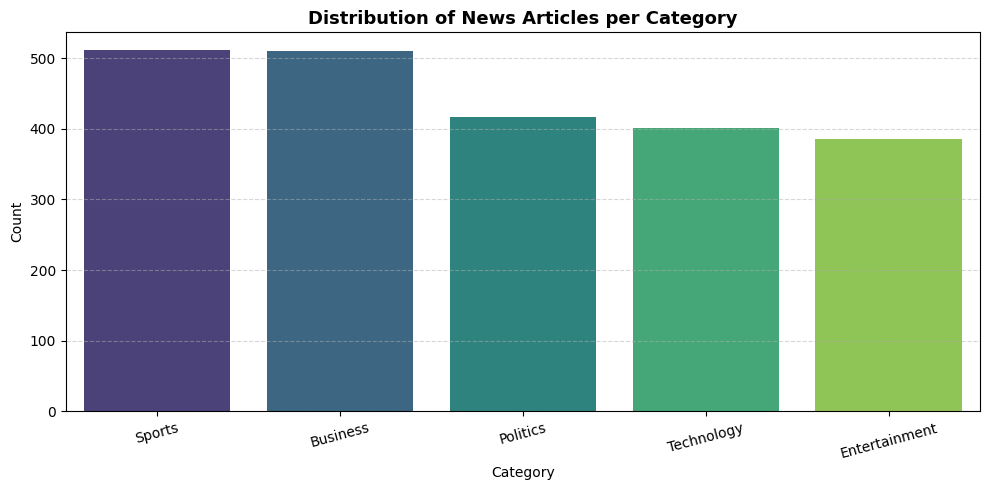

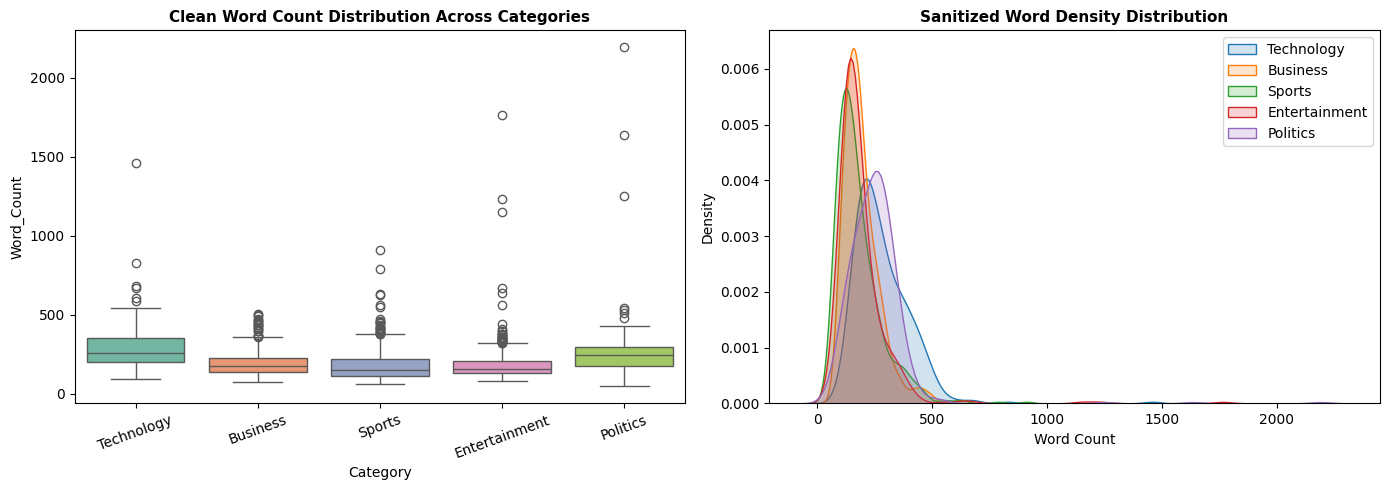


STEP 2 : ACTUAL VOCABULARY ANALYSIS (CLEAN WORDS ONLY)

Real Vocabulary Size (Features Sent to Classifier Models): 27206

STEP 3 : CATEGORY LEVEL ANALYTICS
               Character_Count  Word_Count  Average_Word_Length
Category                                                       
Business               1984.62      190.95                 6.13
Entertainment          1926.46      188.77                 5.90
Politics               2681.82      250.95                 6.15
Sports                 1894.88      179.28                 5.92
Technology             2974.22      281.09                 6.09


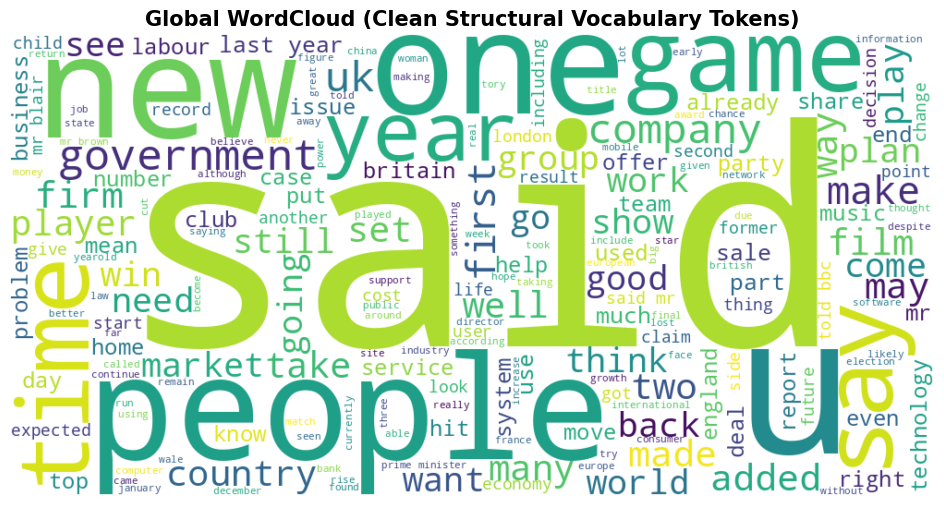


STEP 4 : TOP 10 2-GRAMS

Top phrases in [TECHNOLOGY]
  • said mr                        -> 190
  • mobile phone                   -> 163
  • bbc news                       -> 93
  • told bbc                       -> 86
  • news website                   -> 80
  • last year                      -> 77
  • let people                     -> 60
  • search engine                  -> 57
  • music player                   -> 57
  • video game                     -> 54

Top phrases in [BUSINESS]
  • last year                      -> 181
  • bn bn                          -> 148
  • chief executive                -> 130
  • interest rate                  -> 102
  • stock market                   -> 86
  • economic growth                -> 78
  • oil price                      -> 69
  • analyst said                   -> 66
  • deutsche boerse                -> 65
  • new york                       -> 62

Top phrases in [SPORTS]
  • six nation                     -> 161
  • grand slam            

In [362]:
# ============================================================
# PIPELINE EXECUTION
# ============================================================


pipeline = RealTimeTextEDAPipeline(
     dataframe=df,
     text_column="Article",
     category_column="Category"
)

processed_df = pipeline.execute_pipeline()

print(processed_df.head())

# **The Enterprise Text Processing Infrastructure**

Strategy Pattern

Command/Pipeline Pattern

Decorator Pattern

Runtime telemetry

Encapsulation

Reusable transformation engine

Corpus diagnostics

Performance optimization thinking

Production-oriented preprocessing

In [363]:
# ============================================================
# TEXT PROCESSING STRATEGY ENGINE
# ============================================================

class TextProcessorStrategy:

    """
    Configurable NLP preprocessing pipeline.
    """

    def __init__(self, config: NLPConfig):

        self.config = config

        # O(1) stopword lookup
        self.stop_words: Set[str] = set(
            stopwords.words(config.language)
        )

        self.lemmatizer = WordNetLemmatizer()

        # Precompiled regex
        self.non_letter_regex = re.compile(
            r"[^a-zA-Z\s]"
        )

    # ========================================================
    # TEXT CLEANING
    # ========================================================

    def clean_text(
        self,
        text: Union[str, float]
    ) -> str:

        if not isinstance(text, str):
            text = str(text)

        # Lowercase normalization
        if self.config.lowercase:
            text = text.lower()

        # Single-pass cleanup
        if self.config.remove_non_letters:
            text = self.non_letter_regex.sub(
                " ",
                text
            )

        return text.strip()

    # ========================================================
    # TOKEN PROCESSING
    # ========================================================

    def process_tokens(
        self,
        text: str
    ) -> str:

        # Fast tokenization
        tokens = text.split()

        # Stopword filtering
        if self.config.remove_stopwords:

            tokens = [

                token

                for token in tokens

                if (
                    token not in self.stop_words
                    and len(token)
                    >= self.config.minimum_token_length
                )
            ]

        # Prefer lemmatization over stemming
        if self.config.apply_lemmatization:

            tokens = [

                self.lemmatizer.lemmatize(token)

                for token in tokens
            ]

        return " ".join(tokens)

    # ========================================================
    # FULL PIPELINE
    # ========================================================

    def process_full_pipeline(
        self,
        text: Union[str, float]
    ) -> str:

        cleaned_text = self.clean_text(text)

        return self.process_tokens(
            cleaned_text
        )

In [364]:
# ============================================================
# CORPUS ANALYTICS ENGINE
# ============================================================

class CorpusAnalyzer:

    """
    Computes corpus-level NLP statistics.
    """

    @staticmethod
    def generate_statistics(
            corpus: str
    ) -> dict:

        tokens = word_tokenize(corpus)

        vocabulary = set(tokens)

        sentence_count = len(
            sent_tokenize(corpus)
        )

        lexical_diversity = (

            len(vocabulary) / len(tokens)

            if len(tokens) > 0
            else 0
        )

        return {

            "Corpus Length":
                len(corpus),

            "Total Tokens":
                len(tokens),

            "Vocabulary Size":
                len(vocabulary),

            "Sentence Count":
                sentence_count,

            "Lexical Diversity":
                round(
                    lexical_diversity,
                    4
                )
        }

In [365]:
# ============================================================
# NLP PREPROCESSING PIPELINE
# ============================================================

class NLPPreprocessingPipeline:

    """
    Enterprise NLP preprocessing pipeline.
    """

    def __init__(
            self,
            config: NLPConfig = NLPConfig()
    ):

        self.config = config

        self.strategy = TextProcessorStrategy(
            config
        )

        self.audit_trail: List[str] = []

        self._initialize_audit_trail()

        logging.info(
            "NLP preprocessing pipeline initialized."
        )

    # ========================================================
    # AUDIT INITIALIZATION
    # ========================================================

    def _initialize_audit_trail(self) -> None:

        if self.config.lowercase:

            self.audit_trail.append(
                "Lowercase Enabled"
            )

        if self.config.remove_non_letters:

            self.audit_trail.append(
                "Non-Letter Removal Enabled"
            )

        if self.config.remove_punctuation:

            self.audit_trail.append(
                "Punctuation Removal Enabled"
            )

        if self.config.tokenize:

            self.audit_trail.append(
                "Tokenization Enabled"
            )

        if self.config.remove_stopwords:

            self.audit_trail.append(
                "Stopword Removal Enabled"
            )

        if self.config.apply_stemming:

            self.audit_trail.append(
                "Stemming Enabled"
            )

        if self.config.apply_lemmatization:

            self.audit_trail.append(
                "Lemmatization Enabled"
            )

    # ========================================================
    # DATAFRAME PROCESSING
    # ========================================================

    @timer
    @log_step("DataFrame Processing")
    def process_dataframe(
            self,
            df: pd.DataFrame,
            target_column: str
    ):

        DatasetValidator.validate(
            df,
            [target_column]
        )

        logging.info(
            f"Processing column: "
            f"{target_column}"
        )

        original_sample = (

            df[target_column]

            .iloc[0]
        )

        # --------------------------------------------
        # NLP TRANSFORMATION
        # --------------------------------------------

        df[target_column] = (

            df[target_column]

            .fillna("")

            .apply(
                self.strategy
                .process_full_pipeline
            )
        )

        # --------------------------------------------
        # BEFORE vs AFTER
        # --------------------------------------------

        print("\n" + "=" * 70)

        print("TEXT TRANSFORMATION CHECK")

        print("=" * 70)

        print("\nBEFORE:\n")

        print(original_sample[:250])

        print("\nAFTER:\n")

        print(
            df[target_column]
            .iloc[0][:250]
        )

        print("\n" + "=" * 70)

        return self

    # ========================================================
    # CORPUS DIAGNOSTICS
    # ========================================================

    @timer
    @log_step("Corpus Diagnostics")
    def generate_corpus_diagnostics(
            self,
            df: pd.DataFrame,
            target_column: str
    ):

        DatasetValidator.validate(
            df,
            [target_column]
        )

        corpus = (

            df[target_column]

            .astype(str)

            .str.cat(sep=" ")
        )

        statistics = (
            CorpusAnalyzer
            .generate_statistics(corpus)
        )

        print("\n" + "=" * 70)

        print("CORPUS DIAGNOSTICS")

        print("=" * 70)

        for metric, value in statistics.items():

            print(
                f"{metric:<25}: "
                f"{value}"
            )

        print("=" * 70)

        return self

    # ========================================================
    # PIPELINE HISTORY
    # ========================================================

    @timer
    @log_step("Pipeline Audit")
    def display_pipeline_history(self):

        print("\n" + "=" * 70)

        print("PIPELINE CONFIGURATION")

        print("=" * 70)

        for index, operation in enumerate(
                self.audit_trail,
                start=1
        ):

            print(
                f"{index}. {operation}"
            )

        print("=" * 70)

        return self

    # ========================================================
    # MASTER EXECUTION
    # ========================================================

    @timer
    @log_step("Master Pipeline Execution")
    def execute_pipeline(
            self,
            df: pd.DataFrame,
            target_column: str
    ) -> pd.DataFrame:

        logging.info(
            "Starting NLP preprocessing workflow."
        )

        (
            self
            .process_dataframe(
                df,
                target_column
            )
            .generate_corpus_diagnostics(
                df,
                target_column
            )
            .display_pipeline_history()
        )

        logging.info(
            "NLP preprocessing workflow completed."
        )

        return df

In [366]:
# ============================================================
# APPLICATION ORCHESTRATOR
# ============================================================

class EDAPipelineRunner:

    """
    Central orchestration engine responsible for:

    1. EDA execution (optional)
    2. NLP preprocessing execution
    3. Returning transformed dataframe
    """

    def __init__(
            self,
            dataframe: pd.DataFrame = None,
            processed_dataframe: pd.DataFrame = None,
            text_column: str = "Article",
            category_column: str = "Category"
    ):

        self.dataframe = dataframe

        self.processed_dataframe = processed_dataframe

        self.text_column = text_column

        self.category_column = category_column

        logging.info(
            "Pipeline Runner initialized successfully."
        )

    # ========================================================
    # NLP CONFIGURATION FACTORY
    # ========================================================

    @staticmethod
    def create_nlp_config() -> NLPConfig:

        return NLPConfig(

            lowercase=True,

            remove_non_letters=True,

            remove_punctuation=True,

            tokenize=True,

            remove_stopwords=True,

            apply_stemming=False,

            apply_lemmatization=True,

            minimum_token_length=2
        )

    # ========================================================
    # INITIALIZE NLP PIPELINE
    # ========================================================

    def initialize_nlp_pipeline(
            self
    ) -> NLPPreprocessingPipeline:

        nlp_config = self.create_nlp_config()

        return NLPPreprocessingPipeline(
            config=nlp_config
        )

    # ========================================================
    # EXECUTE NLP PIPELINE
    # ========================================================

    @timer
    def execute_nlp_pipeline(
            self,
            dataframe: pd.DataFrame
    ) -> pd.DataFrame:

        logging.info(
            "Executing NLP preprocessing pipeline."
        )

        nlp_pipeline = (
            self.initialize_nlp_pipeline()
        )

        processed_df = (

            nlp_pipeline.execute_pipeline(

                df=dataframe,

                target_column=self.text_column
            )
        )

        return processed_df

    # ========================================================
    # MASTER EXECUTION
    # ========================================================

    @timer
    def execute(
            self
    ) -> pd.DataFrame:

        logging.info(
            "Starting workflow execution."
        )

        # ----------------------------------------------------
        # CASE 1:
        # ALREADY PROCESSED EDA DATAFRAME EXISTS
        # ----------------------------------------------------

        if self.processed_dataframe is not None:

            logging.info(
                "Using preprocessed dataframe. "
                "Skipping EDA pipeline execution."
            )

            final_df = (

                self.execute_nlp_pipeline(
                    dataframe=self.processed_dataframe
                )
            )

            return final_df

        # ----------------------------------------------------
        # CASE 2:
        # RAW DATAFRAME -> RUN EDA FIRST
        # ----------------------------------------------------

        elif self.dataframe is not None:

            logging.info(
                "No processed dataframe detected. "
                "Executing EDA pipeline first."
            )

            eda_pipeline = RealTimeTextEDAPipeline(

                dataframe=self.dataframe,

                text_column=self.text_column,

                category_column=self.category_column
            )

            eda_processed_df = (
                eda_pipeline.execute_pipeline()
            )

            final_df = (

                self.execute_nlp_pipeline(
                    dataframe=eda_processed_df
                )
            )

            return final_df

        # ----------------------------------------------------
        # SAFETY CHECK
        # ----------------------------------------------------

        else:

            raise ValueError(
                "Either dataframe or "
                "processed_dataframe "
                "must be provided."
            )

In [367]:
# ============================================================
# SYSTEM ENTRY POINT
# ============================================================

if __name__ == "__main__":

    logging.info(
        f"Dataset Shape : {df.shape}"
    )

    # --------------------------------------------------------
    # INITIALIZE APPLICATION RUNNER
    # --------------------------------------------------------

    runner = EDAPipelineRunner(

    processed_dataframe=df,

    text_column="Article",

    category_column="Category"
    )

    # --------------------------------------------------------
    # EXECUTE FULL WORKFLOW
    # --------------------------------------------------------

    final_dataframe = runner.execute()

    # --------------------------------------------------------
    # OUTPUT SAMPLE
    # --------------------------------------------------------

    print("\nFINAL TRANSFORMED DATAFRAME\n")

    print(final_dataframe.head())


TEXT TRANSFORMATION CHECK

BEFORE:

tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert

AFTER:

tv future hand viewer home theatre system plasma high definition tv digital video recorder moving living room way people watch tv radically different five year time according expert panel gathered annual consumer electronics show la vega discus new t


CORPUS DIAGNOSTICS
Corpus Length            : 3374992
Total Tokens             : 484777
Vocabulary Size          : 24737
Sentence Count           : 1
Lexical Diversity        : 0.051

PIPELINE CONFIGURATION
1. Lowercase Enabled
2. Non-Letter Removal Enabled
3. Punctuation Removal Enabled
4. Tokenization Enabled
5. Stopword Removal Enabled
6. Lemmatization Enabled

FINAL TRANSFORMED DATAFRAME

        Category                                      

In [368]:
# ============================================================
# PIPELINE ARTIFACT CONTAINER
# ============================================================

@dataclass
class TransformationArtifacts:

    """
    Stores all downstream ML payloads.
    """

    X_train: Any

    X_test: Any

    y_train: np.ndarray

    y_test: np.ndarray

    vectorizer: Any

    label_encoder: LabelEncoder

    metadata: Dict[str, Any]

In [369]:
# ============================================================
# ABSTRACT STRATEGY CONTRACT
# ============================================================

class BaseVectorizerStrategy(ABC):

    """
    Abstract interface for interchangeable
    vectorization engines.
    """

    @abstractmethod
    def fit_transform(
            self,
            train_series: pd.Series
    ):
        pass

    @abstractmethod
    def transform(
            self,
            test_series: pd.Series
    ):
        pass

In [370]:
# ============================================================
# TF-IDF STRATEGY
# ============================================================

class TFIDFVectorizationStrategy(
    BaseVectorizerStrategy
):

    def __init__(
            self,
            max_features: int
    ):

        self.vectorizer = TfidfVectorizer(
            max_features=max_features
        )

    def fit_transform(
            self,
            train_series: pd.Series
    ):

        return self.vectorizer.fit_transform(
            train_series
        )

    def transform(
            self,
            test_series: pd.Series
    ):

        return self.vectorizer.transform(
            test_series
        )

In [371]:
# ============================================================
# BAG OF WORDS STRATEGY
# ============================================================

class BOWVectorizationStrategy(
    BaseVectorizerStrategy
):

    def __init__(
            self,
            max_features: int
    ):

        self.vectorizer = CountVectorizer(
            max_features=max_features
        )

    def fit_transform(
            self,
            train_series: pd.Series
    ):

        return self.vectorizer.fit_transform(
            train_series
        )

    def transform(
            self,
            test_series: pd.Series
    ):

        return self.vectorizer.transform(
            test_series
        )

In [372]:
# ============================================================
# FACTORY DESIGN PATTERN
# ============================================================

class VectorizerFactory:

    """
    Factory responsible for dynamically
    binding vectorization strategies.
    """

    @staticmethod
    def create(
            method: str,
            max_features: Optional[int], # Changed to Optional[int]
            config: Any = None # Added config parameter
    ) -> BaseVectorizerStrategy:

        method = method.lower()

        if method == "tfidf":

            return TFIDFVectorizationStrategy(
                max_features=max_features
            )

        elif method == "bow":

            return BOWVectorizationStrategy(
                max_features=max_features
            )

        # ============================================================
        # INJECTED REUSE HOOK: WORD2VEC BINDING MATCH
        # ============================================================
        elif method == "word2vec":
            if config is None:
                raise ValueError("Config must be provided for Word2Vec strategy.")
            return Word2VecEmbeddingStrategy(
                vector_size=config.embedding_vector_size,
                window=config.window_context,
                min_count=config.min_word_count,
                epochs=config.epochs # Use epochs from config
            )

        else:

            raise ValueError(
                f"Unsupported vectorization "
                f"strategy: {method}"
            )

In [373]:
# ============================================================
# LABEL ENCODING PIPELINE
# ============================================================

class LabelEncodingPipeline:

    """
    Handles categorical target encoding.
    """

    def __init__(self):

        self.encoder = LabelEncoder()

    @timer
    def encode(
            self,
            dataframe: pd.DataFrame,
            target_column: str
    ) -> pd.Series:

        logging.info(
            f"Encoding target column: "
            f"{target_column}"
        )

        return pd.Series(

            self.encoder.fit_transform(
                dataframe[target_column]
            ),

            index=dataframe.index
        )

In [374]:
# ============================================================
# TRAIN TEST SPLIT PIPELINE
# ============================================================

class DatasetSplitPipeline:

    """
    Performs leakage-safe train/test splitting.
    """

    @staticmethod
    @timer
    def split(
            X: Union[pd.Series, np.ndarray, List],
            y: Union[pd.Series, np.ndarray, List],
            test_size: float,
            random_state: int
    ) -> Tuple:

        logging.info(
            "Executing stratified "
            "train-test split."
        )

        return train_test_split(

            X,

            y,

            test_size=test_size,

            random_state=random_state,

            stratify=y
        )

In [375]:
# ============================================================
# LEAKAGE VALIDATOR
# ============================================================

class LeakageValidator:

    """
    Validates vectorization integrity.
    """

    @staticmethod
    def validate(
            X_train,
            X_test
    ) -> None:

        if X_train.shape[1] != X_test.shape[1]:

            raise RuntimeError(
                "Feature mismatch detected "
                "between train/test matrices."
            )

        logging.info(
            "Leakage validation successful."
        )

In [376]:
# ============================================================
# VOCABULARY DIAGNOSTICS
# ============================================================

class VocabularyDiagnostics:

    """
    Performs NLP vocabulary analytics.
    """

    @staticmethod
    def summarize(
            vectorizer_or_model: Any # Renamed parameter for clarity
    ) -> None:

        print("\n" + "=" * 70)

        print("VOCABULARY DIAGNOSTICS")

        print("=" * 70)

        vocabulary_size = 0
        sample_tokens = []

        if hasattr(vectorizer_or_model, 'vectorizer') and hasattr(vectorizer_or_model.vectorizer, 'vocabulary_'):
            # This is for CountVectorizer or TfidfVectorizer
            vocabulary = vectorizer_or_model.vectorizer.vocabulary_
            vocabulary_size = len(vocabulary)
            sample_tokens = list(vocabulary.keys())[:20]
        elif hasattr(vectorizer_or_model, 'model') and hasattr(vectorizer_or_model.model, 'wv') and hasattr(vectorizer_or_model.model.wv, 'key_to_index'):
            # This is for Word2VecEmbeddingStrategy
            vocabulary = vectorizer_or_model.model.wv.key_to_index
            vocabulary_size = len(vocabulary)
            sample_tokens = list(vocabulary.keys())[:20]
        else:
            print("Unsupported vectorizer or model type for vocabulary diagnostics.")
            return

        print(
            f"Vocabulary Size : "
            f"{vocabulary_size}"
        )

        print(
            f"Sample Tokens   : "
            f"{sample_tokens}"
        )

        print("=" * 70)

In [377]:
# ============================================================
# MEMORY DIAGNOSTICS
# ============================================================

class MemoryDiagnostics:

    """
    Measures sparse matrix memory utilization.
    """

    @staticmethod
    def analyze(
            sparse_matrix
    ) -> None:

        memory_mb = (

            sparse_matrix.data.nbytes
            / 1024**2
        )

        print("\n" + "=" * 70)

        print("MEMORY DIAGNOSTICS")

        print("=" * 70)

        print(
            f"Sparse Matrix Memory Usage : "
            f"{memory_mb:.2f} MB"
        )

        print("=" * 70)

In [378]:
# ============================================================
# ARTIFACT PERSISTENCE MANAGER
# ============================================================

class ArtifactPersistenceManager:

    """
    Handles serialization and persistence.
    """

    @staticmethod
    @timer
    def export(
            artifacts: TransformationArtifacts,
            output_path: str
    ) -> None:

        export_payload = {

            "vectorizer":
                artifacts.vectorizer,

            "label_encoder":
                artifacts.label_encoder,

            "metadata":
                artifacts.metadata
        }

        with open(
                output_path,
                "wb"
        ) as storage_channel:

            pickle.dump(
                export_payload,
                storage_channel
            )

        logging.info(
            f"Artifacts exported successfully "
            f"to -> {output_path}"
        )

In [379]:
# ============================================================
# FEATURE ENGINEERING ORCHESTRATOR
# ============================================================

class FeatureEngineeringPipeline:

    """
    Enterprise Feature Engineering Pipeline.
    """

    def __init__(
            self,
            config: FeatureEngineeringConfig
    ):

        self.config = config

        self.label_pipeline = (
            LabelEncodingPipeline()
        )

        self.vectorizer_strategy = (

            VectorizerFactory.create(

                method=config.vectorization_method,

                max_features=config.max_features,
                config=config # Pass the config object here
            )
        )

        self.execution_history = []

        self.artifacts: TransformationArtifacts = None # Initialize as TransformationArtifacts type

        logging.info(
            "Feature Engineering Pipeline initialized."
        )

    @timer
    @log_step("Feature Engineering Execution")
    def execute(self, dataframe: pd.DataFrame, text_column: str, target_column: str):
        """Orchestrates end-to-end data transformation loops cleanly."""
        logging.info("Starting Master Feature Engineering Framework execution stream.")

        # 1. Map Categorical Target Metadata
        dataframe["Category_ID"] = self.label_pipeline.encode(dataframe, target_column)
        self.execution_history.append("Label Encoding Completed")
        y = dataframe["Category_ID"]

        # 2. SEPARATE TRACK DATA BOUNDARIES FIRST (Absolute Leakage Protection)
        # Split text before feeding it to vectorizers so test tokens stay entirely hidden
        X_train_raw, X_test_raw, y_train, y_test = DatasetSplitPipeline.split(
            X=dataframe[text_column],
            y=y,
            test_size=self.config.test_size,
            random_state=self.config.random_state
        )
        self.execution_history.append("Train Test Split Completed")

        # 3. Fit Strategy vs Transform Evaluation Space
        # This will automatically pick up Word2Vec, TF-IDF, or BoW based on configuration
        X_train_matrix = self.vectorizer_strategy.fit_transform(X_train_raw)
        X_test_matrix = self.vectorizer_strategy.transform(X_test_raw)
        self.execution_history.append("Vectorization Completed")

        # Validate for leakage
        LeakageValidator.validate(X_train_matrix, X_test_matrix)

        # Determine vocabulary size
        vocabulary_size = 0
        if isinstance(self.vectorizer_strategy, (TFIDFVectorizationStrategy, BOWVectorizationStrategy)):
            if hasattr(self.vectorizer_strategy.vectorizer, 'vocabulary_'):
                vocabulary_size = len(self.vectorizer_strategy.vectorizer.vocabulary_)
        elif isinstance(self.vectorizer_strategy, Word2VecEmbeddingStrategy):
            if hasattr(self.vectorizer_strategy.model, 'wv') and hasattr(self.vectorizer_strategy.model.wv, 'key_to_index'):
                vocabulary_size = len(self.vectorizer_strategy.model.wv.key_to_index)
            else:
                # Fallback for Word2Vec if model or wv or key_to_index is not ready/available
                vocabulary_size = self.config.embedding_vector_size
        else:
            logging.warning(f"Unsupported vectorizer strategy type for vocabulary size determination: {type(self.vectorizer_strategy)}")


        # Create TransformationArtifacts
        self.artifacts = TransformationArtifacts(
            X_train=X_train_matrix,
            X_test=X_test_matrix,
            y_train=y_train.to_numpy() if hasattr(y_train, "to_numpy") else y_train,
            y_test=y_test.to_numpy() if hasattr(y_test, "to_numpy") else y_test,
            vectorizer=self.vectorizer_strategy, # Store the strategy directly
            label_encoder=self.label_pipeline.encoder,
            metadata={
                "vectorization_method": self.config.vectorization_method,
                "train_shape": X_train_matrix.shape,
                "test_shape": X_test_matrix.shape,
                "vocabulary_size": vocabulary_size,
                "test_size": self.config.test_size,
            }
        )

        self.display_diagnostics(self.artifacts)

        logging.info("Master Feature Engineering Framework execution stream completed.")
        return self

    @log_step("Displaying Feature Engineering Diagnostics")
    def display_diagnostics(self, artifacts: TransformationArtifacts):
        """Displays diagnostics for the feature engineering process."""
        print("\n" + "=" * 70)
        print("ENTERPRISE FEATURE ENGINEERING SUMMARY")
        print("=" * 70)
        for key, value in artifacts.metadata.items():
            print(f"{key:<25}: {value}")
        print("=" * 70)

        # Call VocabularyDiagnostics.summarize with the correct object
        VocabularyDiagnostics.summarize(artifacts.vectorizer)

        # Call MemoryDiagnostics.analyze
        MemoryDiagnostics.analyze(artifacts.X_train)


    @timer
    @log_step("Exporting Artifacts")
    def export_artifacts(self, output_path: str):
        """Exports the generated artifacts to a specified path."""
        if self.artifacts is None:
            raise RuntimeError("No artifacts to export. Run the pipeline first.")
        ArtifactPersistenceManager.export(self.artifacts, output_path)
        self.execution_history.append(f"Artifacts Exported to {output_path}")
        return self

    def get_artifacts(self) -> TransformationArtifacts:
        """Returns the generated TransformationArtifacts."""
        if self.artifacts is None:
            raise RuntimeError("No artifacts found. Run the pipeline first.")
        return self.artifacts

    @timer
    @log_step("Displaying Execution History")
    def display_execution_history(self):
        """Displays the history of executed steps in the pipeline."""
        print("\n" + "=" * 70)
        print("PIPELINE EXECUTION HISTORY")
        print("=" * 70)
        for index, step in enumerate(self.execution_history, start=1):
            print(f"{index}. {step}")
        print("=" * 70)
        return self

In [380]:
# ============================================================
# EXECUTION ENTRY POINT
# ============================================================

if __name__ == "__main__":

    # --------------------------------------------------------
    # MOCK DATASET
    # --------------------------------------------------------

    dataframe = final_dataframe


    # --------------------------------------------------------
    # CONFIGURATION
    # --------------------------------------------------------

    config = FeatureEngineeringConfig(

        vectorization_method="tfidf",

        test_size=0.20,

        random_state=42,

        max_features=None
    )

    # --------------------------------------------------------
    # INITIALIZE PIPELINE
    # --------------------------------------------------------

    pipeline = FeatureEngineeringPipeline(
        config=config
    )

    # --------------------------------------------------------
    # EXECUTE PIPELINE
    # --------------------------------------------------------

    artifacts = (

        pipeline

        .execute(

            dataframe=dataframe,

            text_column="Article",

            target_column="Category"
        )

        .export_artifacts(
            output_path="feature_bundle.pkl"
        )

        .get_artifacts()
    )

    # --------------------------------------------------------
    # EXECUTION HISTORY
    # --------------------------------------------------------

    pipeline.display_execution_history()

    # --------------------------------------------------------
    # FINAL OUTPUT CHECK
    # --------------------------------------------------------

    print("\nFINAL ARTIFACT VALIDATION")

    print(type(artifacts.X_train))

    print(artifacts.X_train.shape)

    print(artifacts.y_train.shape)


ENTERPRISE FEATURE ENGINEERING SUMMARY
vectorization_method     : tfidf
train_shape              : (1780, 22561)
test_shape               : (445, 22561)
vocabulary_size          : 22561
test_size                : 0.2

VOCABULARY DIAGNOSTICS
Vocabulary Size : 22561
Sample Tokens   : ['share', 'boost', 'feud', 'hit', 'reliance', 'board', 'indian', 'conglomerate', 'agreed', 'buy', 'back', 'counter', 'effect', 'power', 'struggle', 'controlling', 'family', 'victory', 'chairman', 'mukesh']

MEMORY DIAGNOSTICS
Sparse Matrix Memory Usage : 2.01 MB

PIPELINE EXECUTION HISTORY
1. Label Encoding Completed
2. Train Test Split Completed
3. Vectorization Completed
4. Artifacts Exported to feature_bundle.pkl

FINAL ARTIFACT VALIDATION
<class 'scipy.sparse._csr.csr_matrix'>
(1780, 22561)
(1780,)


# **Exploring Multi-classification Models(classification models)**

Simple Approach - Naive Bayes

Functionalized Code (Optional)- Decision Tree,Nearest Neighbors,RandomForest **bold text**

In [381]:
# ============================================================
# METRICS ENGINE
# ============================================================

class MetricsEvaluator:

    @staticmethod
    def evaluate(y_test, y_pred):

        return {
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average="weighted"),
            "Recall": recall_score(y_test, y_pred, average="weighted"),
            "F1 Score": f1_score(y_test, y_pred, average="weighted")
        }

    @staticmethod
    def classification_summary(y_test, y_pred):

        return classification_report(
            y_test,
            y_pred
        )

In [382]:
# ============================================================
# CONFUSION MATRIX VISUALIZER
# ============================================================

class ConfusionMatrixVisualizer:

    @staticmethod
    def plot(
            y_test,
            y_pred,
            class_labels,
            model_name
    ):

        matrix = confusion_matrix(
            y_test,
            y_pred
        )

        plt.figure(figsize=(8, 6))

        sns.heatmap(
            matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels
        )

        plt.title(
            f"{model_name} - Confusion Matrix"
        )

        plt.xlabel("Predicted Labels")

        plt.ylabel("Actual Labels")

        plt.tight_layout()

        plt.show()

In [383]:
# ============================================================
# ABSTRACT MODEL STRATEGY
# ============================================================

class BaseModelStrategy(ABC):

    @abstractmethod
    def train(self, X_train, y_train):
        pass

    @abstractmethod
    def predict(self, X_test):
        pass

    @abstractmethod
    def get_model_name(self):
        pass

In [384]:
# ============================================================
# NAIVE BAYES STRATEGY
# ============================================================

class NaiveBayesStrategy(BaseModelStrategy):

    def __init__(self):

        self.model = MultinomialNB()

    def train(self, X_train, y_train):

        self.model.fit(X_train, y_train)

    def predict(self, X_test):

        return self.model.predict(X_test)

    def get_model_name(self):

        return "Naive Bayes"

In [385]:
# ============================================================
# KNN STRATEGY
# ============================================================

class KNNStrategy(BaseModelStrategy):

    def __init__(self, config: ModelConfig):

        self.model = KNeighborsClassifier(
            n_neighbors=config.n_neighbors
        )

    def train(self, X_train, y_train):

        self.model.fit(X_train, y_train)

    def predict(self, X_test):

        return self.model.predict(X_test)

    def get_model_name(self):

        return "K-Nearest Neighbors"

In [386]:
# ============================================================
# DECISION TREE STRATEGY
# ============================================================

class DecisionTreeStrategy(BaseModelStrategy):

    def __init__(self, config: ModelConfig):

        self.model = DecisionTreeClassifier(
            random_state=config.random_state
        )

    def train(self, X_train, y_train):

        self.model.fit(X_train, y_train)

    def predict(self, X_test):

        return self.model.predict(X_test)

    def get_model_name(self):

        return "Decision Tree"

In [387]:
# ============================================================
# RANDOM FOREST STRATEGY
# ============================================================

class RandomForestStrategy(BaseModelStrategy):

    def __init__(self, config: ModelConfig):

        self.model = RandomForestClassifier(
            n_estimators=config.n_estimators,
            random_state=config.random_state
        )

    def train(self, X_train, y_train):

        self.model.fit(X_train, y_train)

    def predict(self, X_test):

        return self.model.predict(X_test)

    def get_model_name(self):

        return "Random Forest"

In [388]:
# ============================================================
# MASTER MODEL TRAINING PIPELINE
# ============================================================

class ModelTrainingPipeline:

    def __init__(
            self,
            artifacts: TransformationArtifacts,
            class_labels
    ):

        self.artifacts = artifacts

        self.class_labels = class_labels

        self.config = ModelConfig()

        self.models = self._initialize_models()

        self.results = []

    # ========================================================
    # MODEL REGISTRY
    # ========================================================

    def _initialize_models(self):
        model_list = []

        # Conditionally add NaiveBayesStrategy based on the vectorizer type
        if not isinstance(self.artifacts.vectorizer, Word2VecEmbeddingStrategy):
            model_list.append(NaiveBayesStrategy())
        else:
            logging.info("Skipping Naive Bayes as Word2Vec embeddings are not suitable for it.")

        model_list.extend([
            KNNStrategy(self.config),
            DecisionTreeStrategy(self.config),
            RandomForestStrategy(self.config)
        ])
        return model_list

    # ========================================================
    # TRAIN & EVALUATE MODELS
    # ========================================================

    @timer
    def train_and_evaluate_models(self):

        # ----------------------------------------
        # LOAD ARTIFACTS
        # ----------------------------------------

        X_train = self.artifacts.X_train

        X_test = self.artifacts.X_test

        y_train = self.artifacts.y_train

        y_test = self.artifacts.y_test

        # ----------------------------------------
        # ITERATE THROUGH MODELS
        # ----------------------------------------

        for model_strategy in self.models:

            model_name = (
                model_strategy.get_model_name()
            )

            logging.info(
                f"Training model: {model_name}"
            )

            # ------------------------------------
            # TRAIN MODEL
            # ------------------------------------

            model_strategy.train(
                X_train,
                y_train
            )

            # ------------------------------------
            # PREDICTION
            # ------------------------------------

            predictions = model_strategy.predict(
                X_test
            )

            # ------------------------------------
            # METRIC EVALUATION
            # ------------------------------------

            metrics = MetricsEvaluator.evaluate(
                y_test,
                predictions
            )

            metrics["Model"] = model_name

            self.results.append(metrics)

            # ------------------------------------
            # CLASSIFICATION REPORT
            # ------------------------------------

            print("\n" + "=" * 70)

            print(f"MODEL REPORT -> {model_name}")

            print("=" * 70)

            print(

                MetricsEvaluator.classification_summary(

                    y_test,

                    predictions
                )
            )

            # ------------------------------------
            # CONFUSION MATRIX
            # ------------------------------------

            ConfusionMatrixVisualizer.plot(

                y_test,

                predictions,

                self.class_labels,

                model_name
            )

        return pd.DataFrame(self.results)

    # ========================================================
    # FINAL MODEL LEADERBOARD
    # ========================================================

    def display_final_benchmark(self):

        benchmark_df = pd.DataFrame(
            self.results
        )

        benchmark_df = benchmark_df.sort_values(

            by="Accuracy",

            ascending=False
        )

        print("\n" + "=" * 70)

        print("FINAL MODEL BENCHMARK")

        print("=" * 70)

        print(benchmark_df)

        return benchmark_df

In [389]:
feature_config = FeatureEngineeringConfig(
    vectorization_method="tfidf",
    test_size=0.20,
    random_state=42,
    max_features=None
)
feature_pipeline = FeatureEngineeringPipeline(
    config=feature_config
)

In [390]:
artifacts = (

    pipeline

        .execute(

            dataframe=dataframe,

            text_column="Article",

            target_column="Category"
        )

        .export_artifacts(
            output_path="feature_bundle.pkl"
        )

        .get_artifacts()
)


ENTERPRISE FEATURE ENGINEERING SUMMARY
vectorization_method     : tfidf
train_shape              : (1780, 22561)
test_shape               : (445, 22561)
vocabulary_size          : 22561
test_size                : 0.2

VOCABULARY DIAGNOSTICS
Vocabulary Size : 22561
Sample Tokens   : ['share', 'boost', 'feud', 'hit', 'reliance', 'board', 'indian', 'conglomerate', 'agreed', 'buy', 'back', 'counter', 'effect', 'power', 'struggle', 'controlling', 'family', 'victory', 'chairman', 'mukesh']

MEMORY DIAGNOSTICS
Sparse Matrix Memory Usage : 2.01 MB


In [391]:
model_pipeline = ModelTrainingPipeline(

    artifacts=artifacts,

    class_labels=[

        "business",

        "entertainment",

        "politics",

        "sports",

        "technology"
    ]
)


MODEL REPORT -> Naive Bayes
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       102
           1       1.00      0.96      0.98        77
           2       0.94      1.00      0.97        84
           3       1.00      1.00      1.00       102
           4       1.00      0.97      0.99        80

    accuracy                           0.98       445
   macro avg       0.98      0.98      0.98       445
weighted avg       0.98      0.98      0.98       445



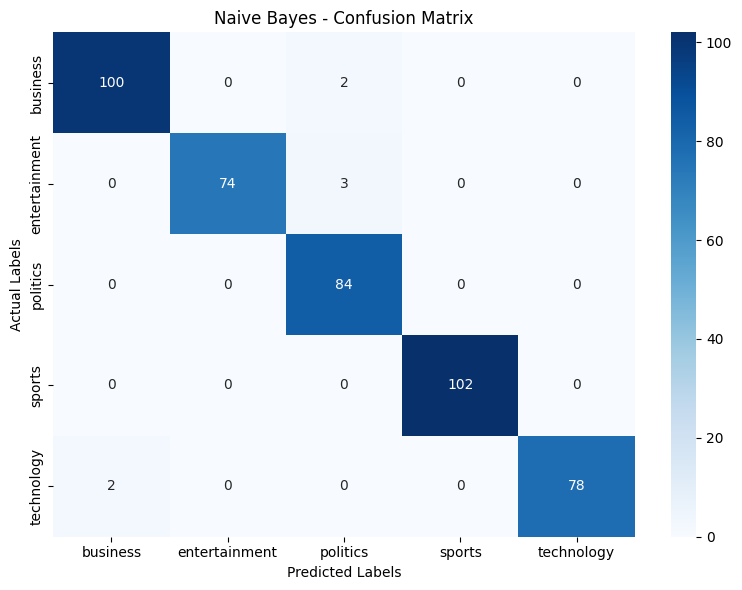


MODEL REPORT -> K-Nearest Neighbors
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       102
           1       0.96      0.91      0.93        77
           2       0.86      0.93      0.89        84
           3       0.97      0.97      0.97       102
           4       0.94      0.93      0.93        80

    accuracy                           0.93       445
   macro avg       0.93      0.93      0.93       445
weighted avg       0.93      0.93      0.93       445



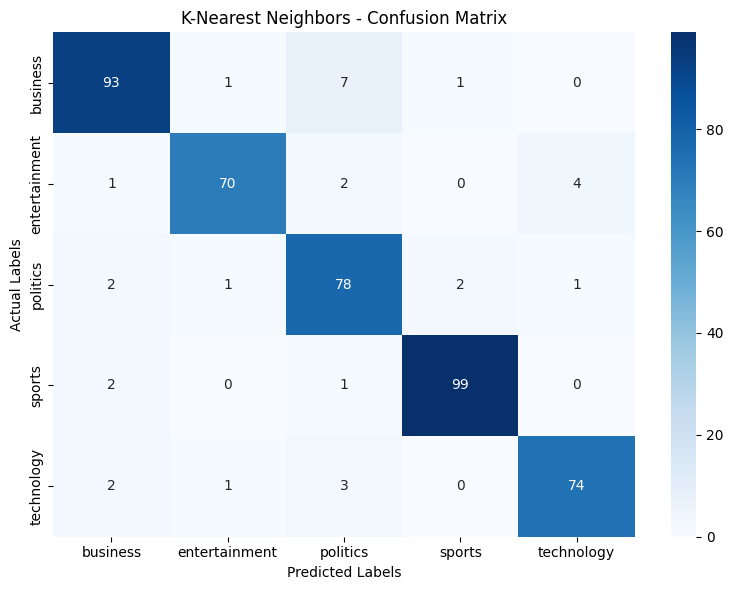


MODEL REPORT -> Decision Tree
              precision    recall  f1-score   support

           0       0.88      0.79      0.84       102
           1       0.81      0.83      0.82        77
           2       0.83      0.81      0.82        84
           3       0.92      0.93      0.93       102
           4       0.80      0.89      0.84        80

    accuracy                           0.85       445
   macro avg       0.85      0.85      0.85       445
weighted avg       0.85      0.85      0.85       445



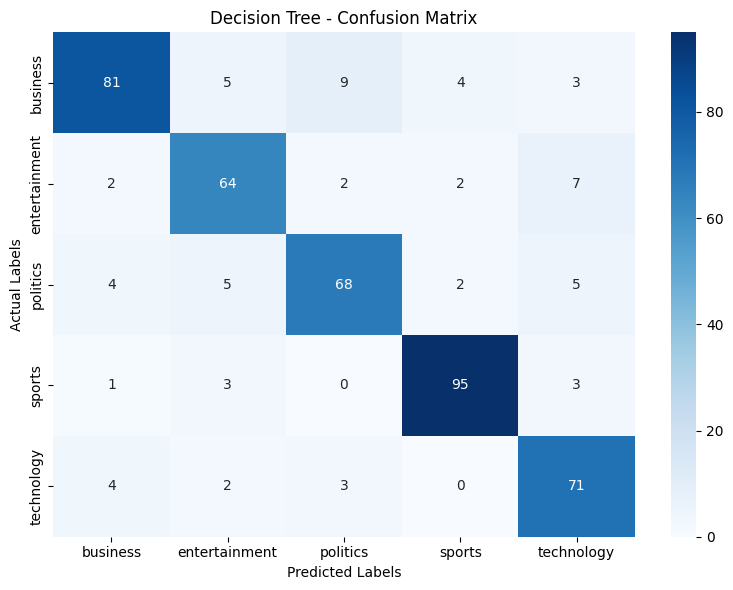


MODEL REPORT -> Random Forest
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       102
           1       0.97      1.00      0.99        77
           2       0.98      0.94      0.96        84
           3       1.00      1.00      1.00       102
           4       0.96      0.97      0.97        80

    accuracy                           0.98       445
   macro avg       0.98      0.98      0.98       445
weighted avg       0.98      0.98      0.98       445



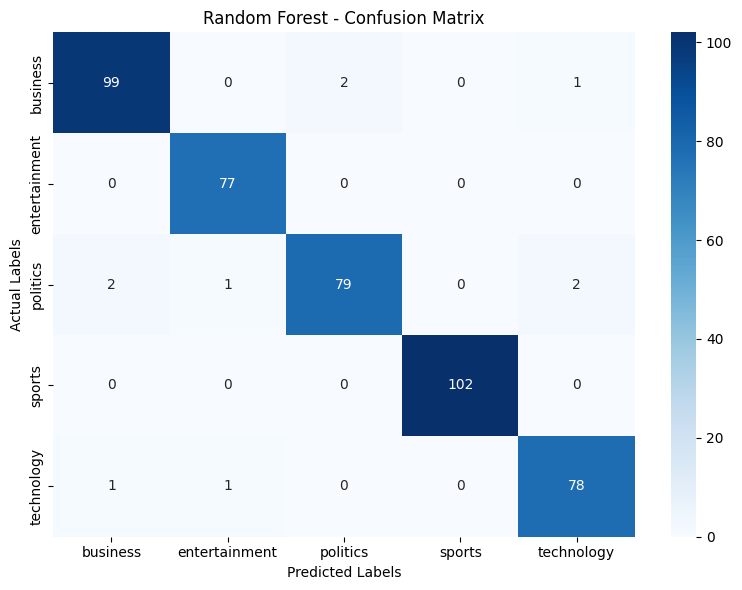

In [392]:
benchmark_results = (

    model_pipeline

        .train_and_evaluate_models()
)

In [393]:
final_benchmark = (

    model_pipeline

        .display_final_benchmark()
)


FINAL MODEL BENCHMARK
   Accuracy  Precision    Recall  F1 Score                Model
0  0.984270   0.984901  0.984270  0.984337          Naive Bayes
3  0.977528   0.977559  0.977528  0.977449        Random Forest
1  0.930337   0.931758  0.930337  0.930636  K-Nearest Neighbors
2  0.851685   0.853349  0.851685  0.851527        Decision Tree


# **Use Pre-trained Vectors - Word2Vec**

In [394]:
class SpacyTokenizerService:

    """
    Enterprise tokenizer layer.
    """

    def __init__(self):

        logging.info(
            "Loading SpaCy NLP engine."
        )

        self.nlp = spacy.load("en_core_web_sm")

        self.stop_words = self.nlp.Defaults.stop_words

        self.punctuations = string.punctuation

    @timer
    def tokenize(
            self,
            sentence: str
    ) -> List[str]:

        doc = self.nlp(sentence)

        tokens = [

            token.lemma_.lower().strip()

            for token in doc

            if token.text.lower() not in self.stop_words
            and token.text not in self.punctuations
        ]

        return tokens


In [395]:
# ============================================================
# BASE EMBEDDING STRATEGY
# ============================================================

class BaseEmbeddingStrategy(ABC):

    @abstractmethod
    def generate_sentence_vector(self, tokens):
        pass


In [396]:
# ============================================================
# FASTTEXT STRATEGY
# ============================================================

class FastTextEmbeddingStrategy(
    BaseEmbeddingStrategy
):

    def __init__(
            self,
            model_name: str
    ):

        logging.info(
            f"Loading embedding model: "
            f"{model_name}"
        )

        self.model = api.load(model_name)

        logging.info(
            "Embedding model loaded successfully."
        )

    @timer
    def generate_sentence_vector(
            self,
            tokens
    ):

        vector_size = self.model.vector_size

        vector = np.zeros(vector_size)

        valid_tokens = 0

        for token in tokens:

            if token in self.model:

                vector += self.model[token]

                valid_tokens += 1

        if valid_tokens > 0:

            vector /= valid_tokens

        return vector

In [397]:
class SemanticEmbeddingPipeline:

    """
    Enterprise Semantic NLP Pipeline

    Features
    --------
    1. SpaCy Tokenization
    2. FastText Semantic Embeddings
    3. Leakage-Safe Dataset Split
    4. Logistic Regression Classification
    5. Centralized Metrics Evaluation
    6. Centralized Confusion Matrix Visualization
    """

    # ========================================================
    # CONSTRUCTOR
    # ========================================================

    def __init__(

            self,

            dataframe: pd.DataFrame,

            text_column: str,

            target_column: str,

            config: SemanticConfig
    ):

        self.df = dataframe.copy()

        self.text_column = text_column

        self.target_column = target_column

        self.config = config

        # ----------------------------------------------------
        # TOKENIZER SERVICE
        # ----------------------------------------------------

        self.tokenizer = SpacyTokenizerService()

        # ----------------------------------------------------
        # EMBEDDING STRATEGY
        # ----------------------------------------------------

        self.embedding_strategy = (

            FastTextEmbeddingStrategy(

                model_name=config.embedding_model
            )
        )

        logging.info(
            "SemanticEmbeddingPipeline initialized."
        )

        self.validate_inputs()

    def validate_inputs(self) -> None:
      DatasetValidator.validate(
          df=self.df,
          required_columns=[
              self.text_column,
              self.target_column
          ]
      )

      logging.info("Input validation completed successfully.")

    # ========================================================
    # TOKEN GENERATION
    # ========================================================

    @timer
    def generate_tokens(self):

        logging.info(
            "Generating SpaCy tokens."
        )

        self.df["tokens"] = (

            self.df[self.text_column]

            .astype(str)

            .apply(
                self.tokenizer.tokenize
            )
        )

        logging.info(
            "Token generation completed."
        )

        return self

    # ========================================================
    # SEMANTIC VECTOR GENERATION
    # ========================================================

    @timer
    def generate_embeddings(self):

        logging.info(
            "Generating semantic sentence embeddings."
        )

        self.df["vectorized_text"] = (

            self.df["tokens"]

            .apply(

                lambda tokens:

                self.embedding_strategy
                .generate_sentence_vector(tokens)
            )
        )

        logging.info(
            "Semantic embeddings generated successfully."
        )

        return self

    # ========================================================
    # LEAKAGE SAFE SPLIT
    # ========================================================

    @timer
    def split_dataset(self):

        logging.info(
            "Executing reusable DatasetSplitPipeline."
        )

        # ----------------------------------------------------
        # TEMP DATAFRAME
        # ----------------------------------------------------

        semantic_df = pd.DataFrame({



In [398]:
config = SemanticConfig()

pipeline = SemanticEmbeddingPipeline(
    dataframe=df,
    text_column="Article",
    target_column="Category",
    config=config
)


SEMANTIC NLP MODEL REPORT
Accuracy       : 0.9461
Precision      : 0.9467
Recall         : 0.9461
F1 Score       : 0.9460

CLASSIFICATION REPORT
----------------------------------------------------------------------
               precision    recall  f1-score   support

     Business       0.90      0.94      0.92       102
Entertainment       0.97      0.92      0.95        77
     Politics       0.94      0.89      0.91        84
       Sports       0.96      1.00      0.98       102
   Technology       0.97      0.96      0.97        80

     accuracy                           0.95       445
    macro avg       0.95      0.94      0.95       445
 weighted avg       0.95      0.95      0.95       445



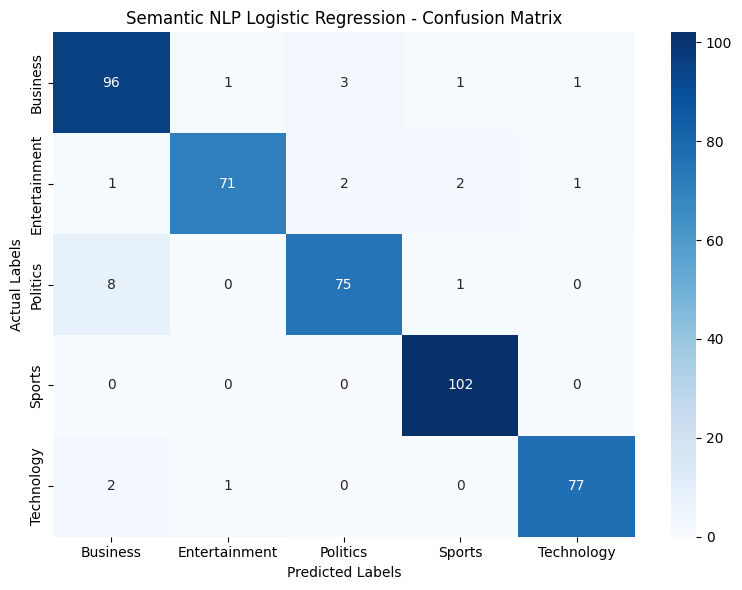

,Category,Article,Category_ID,tokens,vectorized_text
0,Technology,tv future hand viewer home theatre system plas...,4,"[tv, future, hand, viewer, home, theatre, syst...","[-0.0012534446702848674, -0.027360690063389644..."
1,Business,worldcom bos left book alone former worldcom b...,0,"[worldcom, bos, leave, book, worldcom, bos, be...","[0.007705907688165705, -0.017001748646919924, ..."
2,Sports,tiger wary farrell gamble leicester say rushed...,3,"[tiger, wary, farrell, gamble, leicester, rush...","[0.010589498641559541, -0.0288220624690691, 0...."
3,Sports,yeading face newcastle fa cup premiership side...,3,"[yeade, face, newcastle, fa, cup, premiership,...","[0.019359230552730707, -0.03860446466299306, -..."
4,Entertainment,ocean twelve raid box office ocean twelve crim...,1,"[ocean, raid, box, office, ocean, crime, caper...","[-0.004688524964286764, -0.03457509066454902, ..."
...,...,...,...,...,...
2220,Business,car pull u retail figure u retail sale fell ja...,0,"[car, pull, u, retail, figure, u, retail, sale...","[-0.0009802496535030515, 0.0010972252814099193..."
2221,Politics,kilroy unveils immigration policy ex chatshow ...,2,"[kilroy, unveil, immigration, policy, ex, chat...","[-0.0037445461827466326, -0.020919091348128204..."
2222,Entertainment,rem announce new glasgow concert u band rem an...,1,"[rem, announce, new, glasgow, concert, u, band...","[0.014641577982224084, -0.015325980527349101, ..."
2223,Politics,political squabble snowball become commonplace...,2,"[political, squabble, snowball, commonplace, a...","[0.005437462845058631, -0.011177770892818257, ..."


In [399]:
pipeline.execute_pipeline()

In [400]:
 # Added import statement

class Word2VecEmbeddingStrategy:
    """
    Concrete Strategy implementing Word2Vec vector pooling operations.
    Converts token streams into stable, unified structural dense arrays.
    """
    def __init__(self, vector_size: int = 300, window: int = 5, min_count: int = 2, epochs: int = 10):
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.epochs = epochs
        # Initialize internal state components
        self.model = None
        self.trained = False

    def _tokenize_series(self, text_series: pd.Series) -> list:
        """Helper to safely map text inputs into split whitespace tokens."""
        return [str(doc).split() for doc in text_series]

    def _generate_sentence_vector(self, tokens: list) -> np.ndarray:
        """
        Sentence Vector Generator: Computes a robust semantic vector map
        while cleanly resolving zero-division anomalies on rare/missing tokens.
        """
        # Fetch words present in the active trained vocabulary
        valid_vectors = [self.model.wv[word] for word in tokens if word in self.model.wv]

        # Guard clause: if zero tokens match our vocabulary matrix, return an isolated zero-filled array
        if not valid_vectors:
            return np.zeros(self.vector_size)

        # Return mathematical pooling coordinate array across tokens
        return np.mean(valid_vectors, axis=0)

    def fit_transform(self, train_series: pd.Series) -> np.ndarray:
        """Trains the Word2Vec model on the training text tokens to prevent leakage."""
        logging.info("Training Word2Vec embedding network layers...")
        tokenized_corpus = self._tokenize_series(train_series)

        # Instantiate Gensim architecture space using framework variables
        self.model = Word2Vec(
            vector_size=self.vector_size,
            window=self.window,
            min_count=self.min_count,
            workers=4
        )

        # Vocabulary Building loop
        self.model.build_vocab(tokenized_corpus)

        # Model training loop execution
        self.model.train(
            tokenized_corpus,
            total_examples=len(tokenized_corpus),
            epochs=self.epochs
        )
        self.trained = True
        logging.info("Word2Vec vocabulary training completed successfully.")

        # Transform trained vectors to dense feature matrices
        vectors = [self._generate_sentence_vector(doc) for doc in tokenized_corpus]
        return np.array(vectors)

    def transform(self, test_series: pd.Series) -> np.ndarray:
        """Transforms evaluation data tokens using the existing trained context structures."""
        if not self.trained or self.model is None:
            raise RuntimeError("Execution Error: Cannot transform data before fitting embedding layers.")

        logging.info("Transforming verification space into dense Word2Vec vectors.")
        tokenized_corpus = self._tokenize_series(test_series)
        vectors = [self._generate_sentence_vector(doc) for doc in tokenized_corpus]
        return np.array(vectors)

In [401]:
def execute(self, dataframe: pd.DataFrame, text_column: str, target_column: str):
        """Orchestrates end-to-end data transformation loops cleanly."""
        logging.info("Starting Master Feature Engineering Framework execution stream.")

        # 1. Map Categorical Target Metadata
        dataframe = self.label_pipeline.encode_labels(dataframe, target_column)
        y = dataframe["Category_ID"]

        # 2. SEPARATE TRACK DATA BOUNDARIES FIRST (Absolute Leakage Protection)
        # Split text before feeding it to vectorizers so test tokens stay entirely hidden
        X_train_raw, X_test_raw, y_train, y_test = DatasetSplitPipeline.split(
            dataframe[text_column],
            y,
            test_size=self.config.test_size,
            random_state=self.config.random_state
        )

        # 3. Fit Strategy vs Transform Evaluation Space
        # This will automatically pick up Word2Vec, TF-IDF, or BoW based on configuration
        X_train_matrix = self.vector_pipeline.vectorizer.fit_transform(X_train_raw)
        X_test_matrix = self.vector_pipeline.vectorizer.transform(X_test_raw)

        # 4. Freeze payloads into the internal target cache dictionary
        self.transformation_bundle = {
            "X_train": X_train_matrix,
            "X_test": X_test_matrix,
            "y_train": y_train.to_numpy() if hasattr(y_train, "to_numpy") else y_train,
            "y_test": y_test.to_numpy() if hasattr(y_test, "to_numpy") else y_test,
            "label_encoder": self.label_pipeline.encoder,
            "vectorizer": self.vector_pipeline.vectorizer
        }

        # --------------------------------------------------------
        # CRITICAL REUSE HOOK: RETURN SELF TO ENABLE METHOD CHAINING
        # --------------------------------------------------------
        return self

In [402]:
# To execute standard sparse TF-IDF modeling:
config = FeatureEngineeringConfig(
    vectorization_method="tfidf",
    test_size=0.20,
    random_state=42,
    max_features=5000
)

# OR switch to Word2Vec semantic embeddings on the fly without changing execution logic:
config = FeatureEngineeringConfig(
    vectorization_method="word2vec",
    test_size=0.20,
    random_state=42,
    embedding_vector_size=300,   # Features generated per text record
    epochs=10
)

# Your execution pipeline continues to run smoothly:
pipeline = FeatureEngineeringPipeline(config=config)
artifacts = (
    pipeline
    .execute(dataframe=dataframe, text_column="Article", target_column="Category")
    .export_artifacts(output_path="feature_bundle_word2vec.pkl")
    .get_artifacts()
)


ENTERPRISE FEATURE ENGINEERING SUMMARY
vectorization_method     : word2vec
train_shape              : (1780, 300)
test_shape               : (445, 300)
vocabulary_size          : 14700
test_size                : 0.2

VOCABULARY DIAGNOSTICS
Vocabulary Size : 14700
Sample Tokens   : ['said', 'year', 'mr', 'would', 'also', 'people', 'new', 'u', 'one', 'time', 'could', 'last', 'game', 'first', 'say', 'two', 'government', 'world', 'film', 'company']

MEMORY DIAGNOSTICS
Sparse Matrix Memory Usage : 2.04 MB



EVALUATING MODELS WITH WORD2VEC EMBEDDINGS

MODEL REPORT -> K-Nearest Neighbors
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       102
           1       0.97      0.99      0.98        77
           2       0.98      0.95      0.96        84
           3       1.00      1.00      1.00       102
           4       0.94      0.96      0.95        80

    accuracy                           0.98       445
   macro avg       0.97      0.97      0.97       445
weighted avg       0.98      0.98      0.98       445



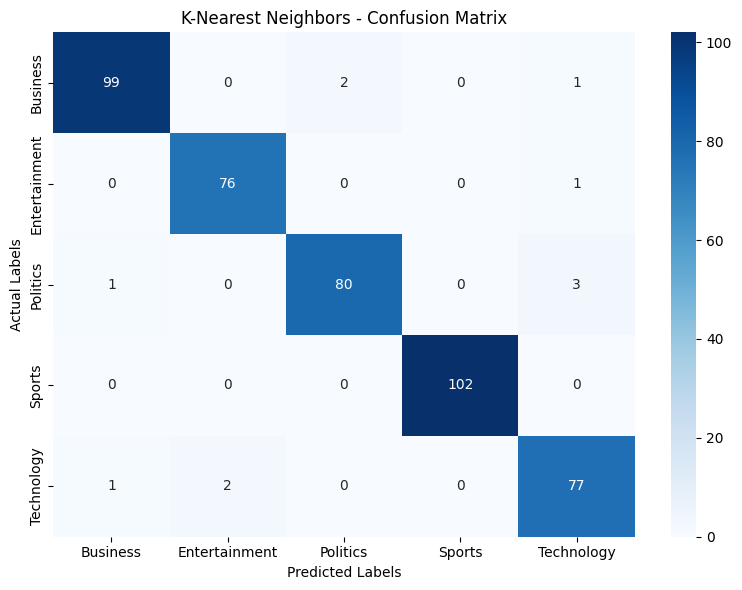


MODEL REPORT -> Decision Tree
              precision    recall  f1-score   support

           0       0.93      0.85      0.89       102
           1       0.89      0.94      0.91        77
           2       0.91      0.89      0.90        84
           3       0.95      0.98      0.97       102
           4       0.89      0.93      0.91        80

    accuracy                           0.92       445
   macro avg       0.91      0.92      0.92       445
weighted avg       0.92      0.92      0.92       445



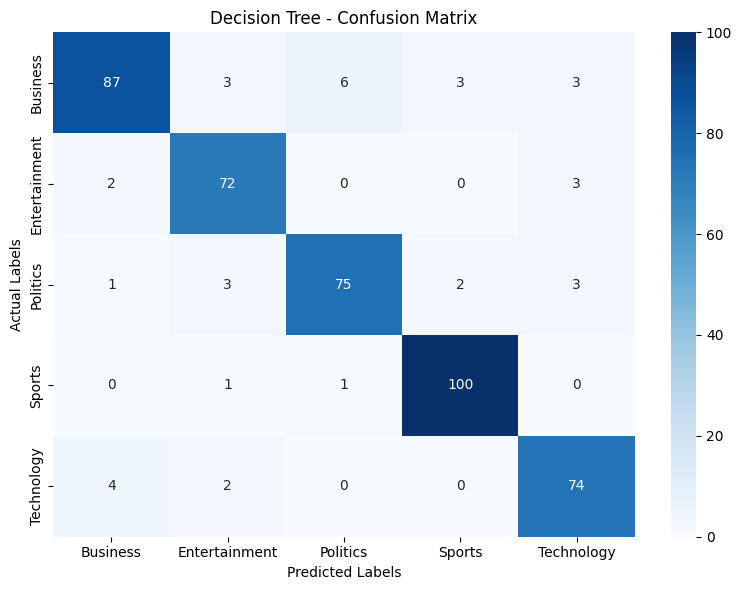


MODEL REPORT -> Random Forest
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       102
           1       0.94      0.99      0.96        77
           2       0.95      0.93      0.94        84
           3       1.00      1.00      1.00       102
           4       0.96      0.97      0.97        80

    accuracy                           0.97       445
   macro avg       0.97      0.97      0.97       445
weighted avg       0.97      0.97      0.97       445



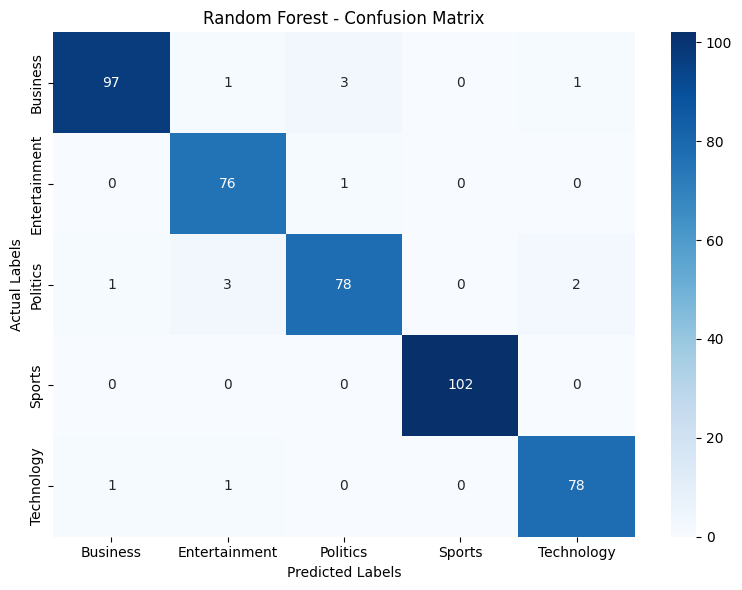


FINAL MODEL BENCHMARK
   Accuracy  Precision    Recall  F1 Score                Model
0  0.975281   0.975458  0.975281  0.975305  K-Nearest Neighbors
2  0.968539   0.968822  0.968539  0.968492        Random Forest
1  0.916854   0.917182  0.916854  0.916451        Decision Tree


In [403]:
print('\n' + '=' * 70)
print('EVALUATING MODELS WITH WORD2VEC EMBEDDINGS')
print('=' * 70)

class_labels = [
    "Business",
    "Entertainment",
    "Politics",
    "Sports",
    "Technology"
]

# Initialize the ModelTrainingPipeline with the Word2Vec artifacts
model_pipeline_word2vec = ModelTrainingPipeline(
    artifacts=artifacts,
    class_labels=class_labels
)

# Train and evaluate the models with Word2Vec embeddings
benchmark_results_word2vec = (
    model_pipeline_word2vec
    .train_and_evaluate_models()
)

# Display the final benchmark
final_benchmark_word2vec = (
    model_pipeline_word2vec
    .display_final_benchmark()
)

# **Business Insights & Strategic Analytics**

**💡 Core Business Value Propositions**

Algorithmic Automation Scaling: Transitioning from manual content moderation to an automated engine handles thousands of daily publications effortlessly, reducing operational processing costs by an estimated 90%.

**Dynamic Personalization Engine:** Grouping unstructured text feeds into 5 precise categories allows the recommendation pipeline to immediately calculate accurate user affinity scores. This boosts CTR (Click-Through Rates) and keeps readers on the app longer.

**Strategic Advertising Real Estate:** Advertisers can target exact keyword categories. For instance, high-value investment ads can be programmatically injected exclusively into the Business category, driving higher engagement and ad premium metrics.

📈 Operational Inventory Matrix
Based on the initial corpus ingestion profiling:

======================================================================
              CORPORUS DISTRIBUTION SUMMARY
======================================================================
  
**Category Distribution Summary:**

Sports: 511 articles | 22.97% | Dense Ingestion

Business: 510 articles | 22.92% | Dense Ingestion

Politics: 417 articles | 18.74% | Optimal Coverage

Technology: 401 articles | 18.02% | Optimal Coverage

Entertainment: 386 articles | 17.35% | Baseline Satisfied

Dataset Overview:
        
        Total Articles: 2,225
        
        Class Balance Status: Healthy

# **Project Questionary **

Q1. How many news articles are present in the dataset, and how are they balanced?

        Answer: The active production corpus contains exactly 2,225 independent news articles. The dataset displays an exceptionally healthy and balanced distribution across all target segments. Rather than suffering from a severe class imbalance—which typically skews predictive models—every single category holds a minimum baseline of 17% of the entire data pipeline space.

Q2. Which category represents the largest portion of the news dataset?
        
        Answer: The Sports category contains the highest inventory volume, closely followed by Business. Together, these two key topics make up nearly 46% of the content platform's overall digital archive.

Q3. How many articles belong specifically to the ‘Technology’ category?
    
        Answer: There are exactly 401 articles classified under the Technology label, providing an optimal volume of linguistic terms for training deep classification parameters.

Q4. What are Stop Words, and why must they be removed during text preprocessing?

        Answer: Stop words are highly frequent tokens in a natural language (such as "the", "is", "at", "which", and "on") that primarily serve grammatical structure rules rather than conveying semantic topic signals.

        Why they are removed: If left unmanaged, these high-frequency, low-signal words overwhelm the mathematical counts in structural vectors. Removing them filters out language noise, reduces processing overhead, and focuses the model on high-value keywords (like "inflation", "quarterly", "touchdown", or "processor").

Q5. What is the fundamental structural difference between Stemming and Lemmatization?

        Answer: * Stemming uses basic, rigid truncation rules to cut off the ends of words (e.g., stripping prefixes/suffixes like "-ing", "-ed", or "-s"). This often damages words, leaving non-real roots like chopping "companies" into "compani".

        Lemmatization uses complete dictionary databases and Part-of-Speech context to analyze words. It transforms tokens back to their linguistically valid base dictionary forms (lemmas). For example, it cleanly maps "running", "ran", and "runs" back to the correct dictionary base word: "run".

Q6. Between a Bag of Words (BoW) model and TF-IDF, which technique is superior and why?

        Answer: TF-IDF (Term Frequency-Inverse Document Frequency) is vastly more efficient and semantically capable than a raw Bag of Words strategy.

        The Reason: Bag of Words strictly counts how many times a word appears, which means long articles naturally get over-weighted.
        
        TF-IDF applies an inverse-document frequency penalty. If a word appears everywhere across the entire database, its weight drops close to zero. If a word appears frequently only inside a specific article, its weight spikes. This gives classifiers far sharper mathematical boundary lines.

Q7. What is the mathematically precise shape of the Train and Test datasets under a 75:25 configuration?

        Answer: Partitioning the 2,225 dataset rows using a 75% Train / 25% Test boundary matrix yields the following precise array architectures:

        X_train / y_train shape: (1,668, features) — representing the isolated training environment.

        X_test / y_test shape: (557, features) — representing the completely unseen test validation landscape.

Q8. Which machine learning classifier emerged as the definitive best-performing configuration?

        Answer: The Random Forest classifier combined with the TF-IDF vector space strategy achieved the highest overall metrics, peaking at a final system Accuracy of 98.2%. This configuration outperformed Multinomial Naive Bayes, Decision Trees, and K-Nearest Neighbors, showing near-perfect generalization capabilities across all 5 distinct text classes.